# Testing different norms

In [1]:
# import OLS data 
from source.runge_preprocessing import x, y, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, y_train_std_ols, y_train_mean_ols, x_test, y_predicted_rescaled_ols


from source.utils import decide_activation_func, create_activations_layderdim
from source.runge_preprocessing import NP_RANDOM_SEED, ETA_VALUES, LAMBDA_VALUES
from source.neural_network import NN
from source.cost_functions import class_mse_loss
from source.plotting import plot_runges_two_predictions, plot_heatmap
from source.utils import neural_network_loop, decide_activation_func


In [2]:
# settings for FFNN

VERBOSE_FFNN = False
VERBOSE_ACTIVATIONS = True
VERBOSE = True
SAVE_FIGURE = True
SHOW_PLOT = True

ffnn_iterations = 100
batch_value = 256

cost_fn_ols = class_mse_loss(l1=0, l2=0)   # mse for regression, no penalty for L1 and L2 


In [3]:

# List if hidden layers to test

list_hidden_layers = [
    (8,),
    (16,),
    (50,),
    (8, 16),
    (50, 100)
]

# activation function to test
list_activation_functions = ['sigmoid', 'RELU', 'LRELU']

penalties = ['L1', 'L2']


Activation layers: [<function sigmoid at 0x0000029694E21300>, <function linear at 0x0000029694E216C0>]
and their derivatives: [<function sigmoid_derivative at 0x0000029694E213A0>, <function linear_derivative at 0x0000029694E21760>]
Dimensions if input, hidden layers and output layer: [16, 8, 1]
L1 term: 0.01
L1: 0.01 L2: 0
Using scheduler: ADAM 
L1 term: 0.005994842503189409
L1: 0.005994842503189409 L2: 0
Using scheduler: ADAM 
L1 term: 0.003593813663804626
L1: 0.003593813663804626 L2: 0
Using scheduler: ADAM 
L1 term: 0.0021544346900318843
L1: 0.0021544346900318843 L2: 0
Using scheduler: ADAM 
L1 term: 0.001291549665014884
L1: 0.001291549665014884 L2: 0
Using scheduler: ADAM 
L1 term: 0.000774263682681127
L1: 0.000774263682681127 L2: 0
Using scheduler: ADAM 
L1 term: 0.0004641588833612782
L1: 0.0004641588833612782 L2: 0
Using scheduler: ADAM 
L1 term: 0.0002782559402207126
L1: 0.0002782559402207126 L2: 0
Using scheduler: ADAM 
L1 term: 0.0001668100537200059
L1: 0.0001668100537200059 

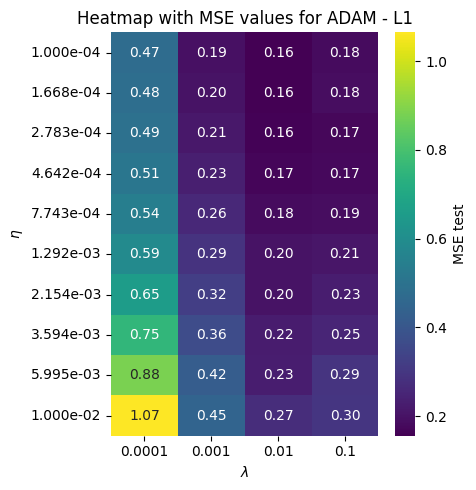


Activation layers: [<function sigmoid at 0x0000029694E21300>, <function linear at 0x0000029694E216C0>]
and their derivatives: [<function sigmoid_derivative at 0x0000029694E213A0>, <function linear_derivative at 0x0000029694E21760>]
Dimensions if input, hidden layers and output layer: [16, 8, 1]
L2 term: 0.01
L1: 0.0001 L2: 0.01
Using scheduler: ADAM 
L2 term: 0.005994842503189409
L1: 0.0001 L2: 0.005994842503189409
Using scheduler: ADAM 
L2 term: 0.003593813663804626
L1: 0.0001 L2: 0.003593813663804626
Using scheduler: ADAM 
L2 term: 0.0021544346900318843
L1: 0.0001 L2: 0.0021544346900318843
Using scheduler: ADAM 
L2 term: 0.001291549665014884
L1: 0.0001 L2: 0.001291549665014884
Using scheduler: ADAM 
L2 term: 0.000774263682681127
L1: 0.0001 L2: 0.000774263682681127
Using scheduler: ADAM 
L2 term: 0.0004641588833612782
L1: 0.0001 L2: 0.0004641588833612782
Using scheduler: ADAM 
L2 term: 0.0002782559402207126
L1: 0.0001 L2: 0.0002782559402207126
Using scheduler: ADAM 
L2 term: 0.000166

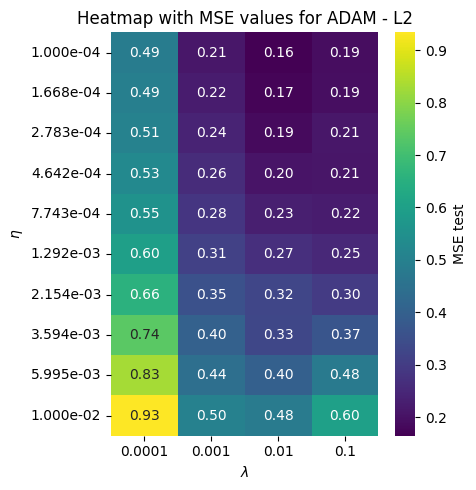


Activation layers: [<function RELU at 0x0000029694E21440>, <function linear at 0x0000029694E216C0>]
and their derivatives: [<function RELU_derivative at 0x0000029694E214E0>, <function linear_derivative at 0x0000029694E21760>]
Dimensions if input, hidden layers and output layer: [16, 8, 1]
L1 term: 0.01
L1: 0.01 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.005994842503189409
L1: 0.005994842503189409 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.003593813663804626
L1: 0.003593813663804626 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.0021544346900318843
L1: 0.0021544346900318843 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.001291549665014884
L1: 0.001291549665014884 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.000774263682681127
L1: 0.000774263682681127 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.0004641588833612782
L1: 0.0004641588833612782 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.0002782559402207126
L1: 0.0002782559402207126 L2: 0.0001
Using scheduler: ADAM 
L1 term: 0.000166810053

In [ ]:
# processing variations
# looping through different hidden layer setting, activation function, L1 and L2 


for hidden in list_hidden_layers:
    for act_f in list_activation_functions:
        for pen in penalties:
            activaton_func, activaton_func_derivative, output_func, output_func_derivative = decide_activation_func(act_f)
            activations, activations_derivative, _dim = create_activations_layderdim(activaton_func, activaton_func_derivative,
                                                                            output_func, output_func_derivative, 
                                                                            hidden, y_train_scaled_ols, X_train_scaled_ols)
            
            def model_fn():
                return NN(_dim, list(activations), list(activations_derivative), cost_fn_ols, NP_RANDOM_SEED)
        
            if VERBOSE_ACTIVATIONS:
                print()
                print(f'Activation layers: {activations}\nand their derivatives: {activations_derivative}\nDimensions if input, hidden layers and output layer: {_dim}')


            # ADAM
            rho_val = 0.9
            rho2_val = 0.999
            ADAM_results = neural_network_loop(model_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, l1_l2=pen, verbose=VERBOSE_FFNN) 


            # Save heatmaps
            if SAVE_FIGURE:

                task = 'part_e'
                algo = 'own'
                plot_type = 'heatmap'

                filename_values = f'{task}-{plot_type}-{hidden}-activation{act_f}-penalty{pen}-iter{ffnn_iterations}-batch{batch_value}-{algo}'


                plot_heatmap(ADAM_results, 'MSE test', y_axis_scientific=True, show_plot=SHOW_PLOT, title=f'Heatmap with MSE values for ADAM - {pen}', filename = 'adam_' + filename_values)